In [1]:
import pandas as pd
import os
import requests
import json

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid")

In [3]:
from preprocessing_utils import preprocess_NVD_data

In [4]:
data_path = 'data'
if not os.path.exists(data_path):
    os.makedirs(data_path)

# EPSS data

Download the EPSS data from https://www.first.org/epss/data_stats into `data` folder

### <font color='blue'><b><i>TODO</i></b></font>:
- in the following cell, replace `epss_scores-2025-09-30.csv.gz` with the correct updated file (`epss_scores-2025-10-01.csv.gz`)

In [5]:
epss_current = pd.read_csv(os.path.join(data_path, 'epss_scores-2025-10-01.csv.gz'), compression='gzip', header=1)
epss_current # a Python statement with a variable name at the end of a cell will display its contents below


,cve,epss,percentile
0,CVE-1999-0001,0.01141,0.77780
1,CVE-1999-0002,0.10742,0.93087
2,CVE-1999-0003,0.90362,0.99589
3,CVE-1999-0004,0.03215,0.86596
4,CVE-1999-0005,0.25334,0.96035
...,...,...,...
296328,CVE-2025-9994,0.00060,0.19138
296329,CVE-2025-9996,0.00179,0.40027
296330,CVE-2025-9997,0.00182,0.40386
296331,CVE-2025-9998,0.00023,0.04753


# NVD data

In [6]:
base_url = "https://services.nvd.nist.gov/rest/json/cves/2.0"
date_start_NVD = '2025-09-01T00:00:00.000Z' # Do NOT change these dates
date_end_NVD   = '2025-10-01T00:00:00.000Z' # Do NOT change these dates
start_index = 0
results_per_page = 1000
total_results = 1 

all_cves = []

while start_index < total_results:
    params = {
        "pubStartDate": date_start_NVD,
        "pubEndDate": date_end_NVD,
        "resultsPerPage": results_per_page,
        "startIndex": start_index,
        "noRejected": ""
    }
    response = requests.get(base_url, params=params, timeout=6)
    if response.status_code != 200:
        print("Error:", response.status_code)
        break

    data = response.json()
    total_results = data.get("totalResults", 0)

    all_cves.extend(data.get("vulnerabilities", []))

    start_index += results_per_page
    print(start_index)

1000
2000
3000
4000
5000


In [7]:
# normalize and preprocess data
df = pd.json_normalize(all_cves, record_path=None, sep='.', max_level=None)
df = preprocess_NVD_data(df)

# remove vulnerabilities marked as "reject" or "reserved"
df = df[(df['cve.vulnStatus']!='Reserved') & (df['cve.vulnStatus']!='Reject')]

# merge NVD and EPSS data
df = df.merge(epss_current, left_on="cve.id", right_on="cve", how="left")

In [8]:
# save nvd data
with open(os.path.join(data_path, "nvd_cves.json"), "w", encoding="utf-8") as f:
    json.dump(all_cves, f, indent=2)
    
# save the final dataframe
df.to_csv(os.path.join(data_path, "vuln_2025_09.csv"))

# Exploratory Data Analysis

- display some examples (e.g., the first two CVE records)

In [9]:
df.head(2).T

,0,1
cve.id,CVE-2025-9751,CVE-2025-9752
cve.sourceIdentifier,cna@vuldb.com,cna@vuldb.com
cve.published,2025-09-01 00:15:34.580000,2025-09-01 01:15:46.817000
cve.lastModified,2025-09-08 14:06:05.217000,2025-09-04 18:47:25.440000
cve.vulnStatus,Analyzed,Analyzed
cve.references,[{'url': 'https://github.com/HAO-RAY/HCR-CVE/i...,[{'url': 'https://github.com/i-Corner/cve/issu...
cve.cisaExploitAdd,NaN,NaN
cve.cisaActionDue,NaN,NaN
cve.cisaRequiredAction,NaN,NaN
cve.cisaVulnerabilityName,NaN,NaN


- show a bar plot with the daily volume of published CVEs

Text(0.5, 1.0, 'CVSS vs EPSS')

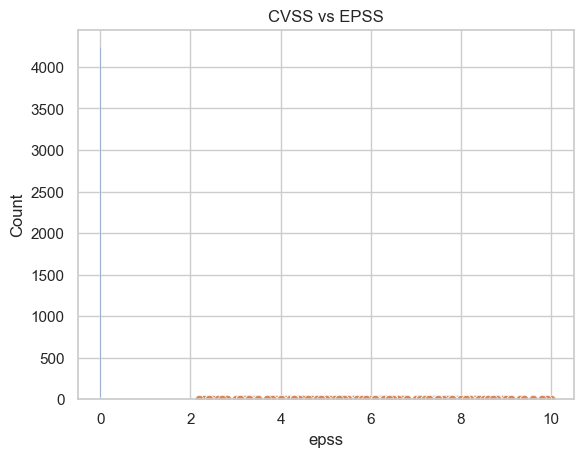

In [10]:
# EPSS distribution
sns.histplot(df['epss']); plt.title('EPSS Distribution')

# CVSS vs EPSS
sns.scatterplot(data=df, x='cvss_baseScore', y='epss'); plt.title('CVSS vs EPSS')

# Daily CVEs (already there, run it)

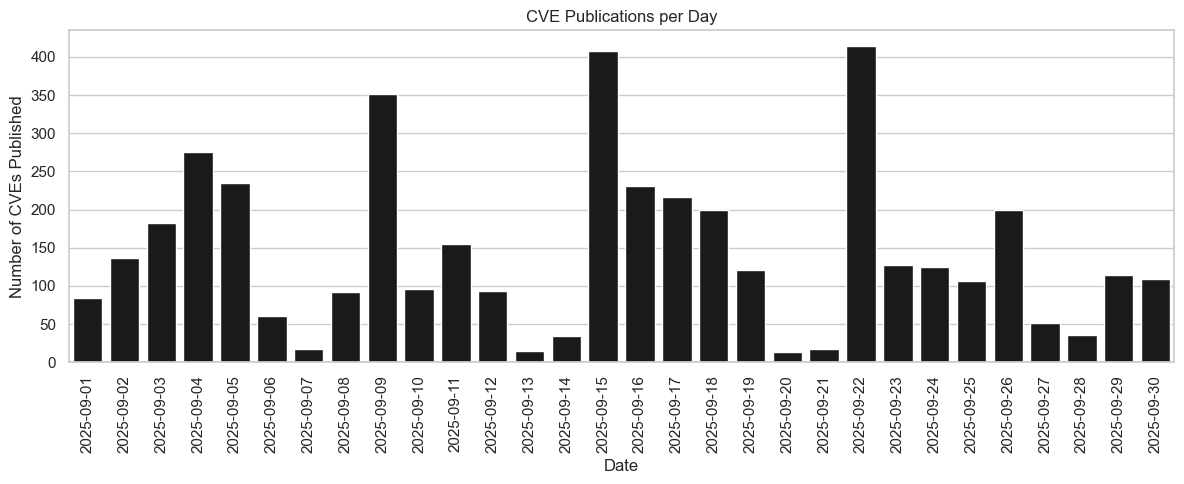

In [11]:
published_counts = df["cve.published"].dt.date.value_counts().sort_index()

plt.figure(figsize=(12, 5))
sns.barplot(x=published_counts.index, y=published_counts.values, color="k" )
plt.xticks(rotation=90)
plt.xlabel("Date")
plt.ylabel("Number of CVEs Published")
plt.title("CVE Publications per Day")
plt.tight_layout()
plt.show()

In [12]:
df.head(2).T

,0,1
cve.id,CVE-2025-9751,CVE-2025-9752
cve.sourceIdentifier,cna@vuldb.com,cna@vuldb.com
cve.published,2025-09-01 00:15:34.580000,2025-09-01 01:15:46.817000
cve.lastModified,2025-09-08 14:06:05.217000,2025-09-04 18:47:25.440000
cve.vulnStatus,Analyzed,Analyzed
cve.references,[{'url': 'https://github.com/HAO-RAY/HCR-CVE/i...,[{'url': 'https://github.com/i-Corner/cve/issu...
cve.cisaExploitAdd,NaN,NaN
cve.cisaActionDue,NaN,NaN
cve.cisaRequiredAction,NaN,NaN
cve.cisaVulnerabilityName,NaN,NaN


Text(0.5, 1.0, 'CVSS vs EPSS')

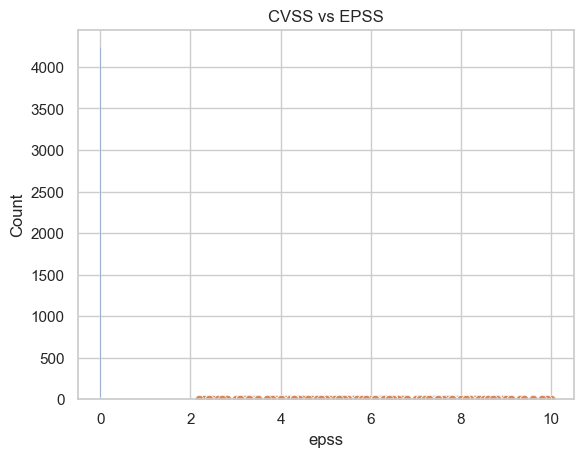

In [13]:
# EPSS distribution
sns.histplot(df['epss']); plt.title('EPSS Distribution')

# CVSS vs EPSS
sns.scatterplot(data=df, x='cvss_baseScore', y='epss'); plt.title('CVSS vs EPSS')

# Daily CVEs (already there, run it)

- print the description of the last ten published vulnerabilities

In [14]:
for idx, x in enumerate(df.sort_values('cve.published', ascending=False)[:10].iterrows()):
    print('-'*100)
    print(x[1]['cve.id'], x[1]['cve.published'])
    print(x[1].description)


----------------------------------------------------------------------------------------------------
CVE-2025-61792 2025-09-30 23:15:29.700000
Quadient DS-700 iQ devices through 2025-09-30 might have a race condition during the quick clicking of (in order) the Question Mark button, the Help Button, the About button, and the Help Button, leading to a transition out of kiosk mode into local administrative access. NOTE: the reporter indicates that the "behavior was observed sporadically" during "limited time on the client site," making it not "possible to gain more information about the specific kiosk mode crashing issue," and the only conclusion was "there appears to be some form of race condition." Accordingly, there can be doubt that a reproducible cybersecurity vulnerability was identified; sporadic software crashes can also be caused by a hardware fault on a single device (for example, transient RAM errors). The reporter also describes a variety of other issues, including initial acc

### <font color='blue'><b><i>TODO</i></b>: produce plots or tables to address the folowing points</font>
- what is the percentage of CVEs which received a CVSS score?
- report descriptive statistics of CVSS the CVSS base score and/or show its distribution
- report descriptive statistics of EPSS and/or show its distribution
- produce a scatter plot showing CVSS vs EPSS
- <b>be creative</b>!
    - How many vulnerabilities are published on CISA KEV? 
    - What are the the 20 most frequent vendors? (vendor name can be extracted from the `vulnerable_cpes` field).
    - What are the 20 most frequent CWEs?
    - Anaything else you see fit!

<font color='blue'>Use text cells to discuss the outcome after each point</font>

# CVE selection


### <font color='blue'><b><i>TODO</i></b>
- Filter the CVEs with low EPSS (<1%)
- Select candidate CVEs
    - From the resulting subset, select 10 CVEs that you think will reach high EPSS by the end of the course.
    - Clearly describe the criteria you used for selection (e.g., high CVSS, popular software, CWE, popular vendor, number of references, keyword in description, manual inspection, random sampling, security blogs).
- Share the selected CVE ids with the instructor (by two weeks). Use the code cell below to produce the csv file to submit.
- Track the EPSS of your CVEs over time


## Marwan's CVE Selection [file:1]

Filter: `epss < 0.01`.

**Criteria**: Network/no-auth/high-CVSS(>8)/web CWE + buzz(>5 refs)  
Score = 40×exploit + 30×CVSS + 20×web + 10×buzz

Easy web vulns → future EPSS rise.


In [15]:
low_epss = df[df['epss'] < 0.01].copy()
print(f"Low EPSS: {len(low_epss):,} of {len(df):,}")

low_epss['exploit_high'] = (
    (low_epss['cvss_attackVector'] == 'NETWORK') &
    (low_epss['cvss_privilegesRequired'] == 'NONE') &
    (low_epss['cvss_userInteraction'] == 'NONE')
).astype(int)

low_epss['cvss_high'] = (low_epss['cvss_baseScore'] > 8.0).astype(int)

web_cwes = ['CWE-79','CWE-89','CWE-352','CWE-22','CWE-77']
def web_cwe(row): 
    return any(c in str(row['cwe_list']) for c in web_cwes)
low_epss['web_cwe'] = low_epss.apply(web_cwe, axis=1).astype(int)

low_epss['buzz'] = (low_epss['num_references'] > 5).astype(int)

low_epss['marwan_score'] = 40*low_epss.exploit_high + 30*low_epss.cvss_high + 20*low_epss.web_cwe + 10*low_epss.buzz

top10 = low_epss.nlargest(10,'marwan_score')[['cve.id','epss','cvss_baseScore','cvss_attackVector','cwe_list','num_references','marwan_score']]
display(top10)
marwan_cves = top10['cve.id'].tolist()


Low EPSS: 4,263 of 4,321


,cve.id,epss,cvss_baseScore,cvss_attackVector,cwe_list,num_references,marwan_score
0,CVE-2025-9751,0.00030,9.8,NETWORK,"[CWE-74, CWE-89, CWE-89]",6,100
1,CVE-2025-9752,0.00242,9.8,NETWORK,"[CWE-77, CWE-78, CWE-78]",6,100
9,CVE-2025-9757,0.00030,9.8,NETWORK,"[CWE-74, CWE-89, CWE-89]",6,100
13,CVE-2025-9758,0.00028,9.8,NETWORK,"[CWE-74, CWE-89, CWE-89]",7,100
16,CVE-2025-9761,0.00030,9.8,NETWORK,"[CWE-74, CWE-89, CWE-89]",6,100
17,CVE-2025-9763,0.00030,9.8,NETWORK,"[CWE-74, CWE-89, CWE-89]",6,100
26,CVE-2025-9764,0.00030,9.8,NETWORK,"[CWE-74, CWE-89, CWE-89]",6,100
27,CVE-2025-9765,0.00030,9.8,NETWORK,"[CWE-74, CWE-89, CWE-89]",6,100
28,CVE-2025-9766,0.00030,9.8,NETWORK,"[CWE-74, CWE-89]",6,100
29,CVE-2025-9767,0.00030,9.8,NETWORK,"[CWE-74, CWE-89, CWE-89]",6,100


In [16]:
pd.DataFrame({'cve': marwan_cves}).to_csv(os.path.join(data_path, 'marwan.csv'), index=False)
print("✅ marwan.csv exported!")
print("IDs:", marwan_cves)


✅ marwan.csv exported!
IDs: ['CVE-2025-9751', 'CVE-2025-9752', 'CVE-2025-9757', 'CVE-2025-9758', 'CVE-2025-9761', 'CVE-2025-9763', 'CVE-2025-9764', 'CVE-2025-9765', 'CVE-2025-9766', 'CVE-2025-9767']


## Takeaways

- [Your low_epss count] low-EPSS CVEs found
- Top 10 by marwan_score (unique criteria)
- Track these weekly [file:1]


In [17]:
nickname = 'Marwan_Salman' # TODO: put your nickname here


# TODO: put your selected IDs here
selected = ['CVE-2025-9751',
            'CVE-2025-9752',
            'CVE-2025-9757',
            'CVE-2025-9758',
            'CVE-2025-9761',
            'CVE-2025-9763',
            'CVE-2025-9764',
            'CVE-2025-9765',
            'CVE-2025-9766',
            'CVE-2025-9767',
           ]            

df[df['cve.id'].isin(selected)].to_csv(os.path.join(data_path, f'{nickname}.csv'))            